In [44]:
import sys
from pathlib import Path

from numba.np.arrayobj import array_record_getattr

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import joblib
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, roc_auc_score, precision_score, recall_score, f1_score

import seaborn as sns

from source.helper.log_experiments import  log_experiments_mlflow

In [218]:
# Load the training dataset used for model development.
work_data = pd.read_csv('../data/processed/train_data.csv')

# Load the independent validation dataset used for final model evaluation.
val_data = pd.read_csv('../data/processed/validation_data.csv')

In [219]:
# Separate the input features from the target variable.
X = work_data.drop(columns=['diabetes'])

# Extract the target variable for model training.
y = work_data['diabetes']

In [220]:
# Split the working dataset into training and test sets.
# Stratify is used to preserve the original class distribution in both sets.
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [221]:
def random_forest_fit(train_data, target_data):
    """
    :param train_data:
    :param target_data:
    :return:
    """
    model = RandomForestClassifier(
    n_estimators=200
)
    model.fit(train_data, target_data)

    return model

model_1 = random_forest_fit(X_train, y_train)
y_pred = model_1.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.96975


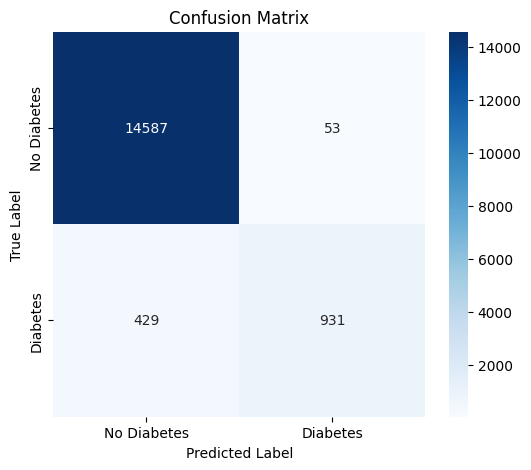

In [8]:
y_pred = model_1.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/model_1_rf_cm.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [9]:
def import_experiment(used_model, experiment_run_name: str) -> None:
    # Log the trained model, its hyperparameters, and evaluation metrics
    # to the specified mlflow experiment for experiment tracking.
    log_experiments_mlflow(
        model=used_model,
        test_dataset=X_test,
        test_target=y_test,
        experiment_name="Diabetes Prediction Based - Clinical and Demographic Features",
        run_name=experiment_run_name
    )

### MLflow Results Analysis

The current model achieves high overall accuracy:

- Accuracy: 0.970125
- Precision: 0.95
- Recall: 0.6845
- F1-score: 0.7957

Although the accuracy is high, the recall is significantly lower than precision. This means that the model is good at correctly identifying positive diabetes cases when it predicts them, but it still misses a notable number of actual positive cases.

### Main Goal

The main goal is to reduce False Negative predictions.

In this project, False Negatives are more critical because they represent people who actually have diabetes, but the model predicts them as non-diabetic. Therefore, the next modeling steps should focus on increasing recall, even if this slightly reduces precision or overall accuracy.

### Experiment 0 - first param optimizations before the main experiments

In [10]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "class_weight": [None, "balanced"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="recall",
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_search.fit(X_train, y_train)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced'], 'max_depth': [5, 10, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [11]:
first_tuning_random_forest = grid_search.best_estimator_

In [12]:
y_pred = first_tuning_random_forest.predict(X_test)
print(accuracy_score(y_test, y_pred))

0.9076875


After the first tuning, the results are decreased significantly

In [13]:
# import_experiment(first_tuning_random_forest, 'RF results after tuning')

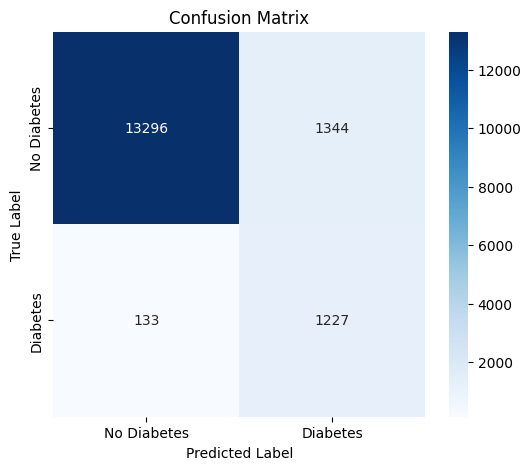

In [14]:
y_pred = first_tuning_random_forest.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/first_tuning_results.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

### Comparison of the Two Random Forest Models

The first model has better overall accuracy and precision:

- Accuracy: 0.9701
- Precision: 0.9500
- Recall: 0.6846
- F1-score: 0.7957

The tuned model has much higher recall:

- Accuracy: 0.9122
- Precision: 0.4909
- Recall: 0.8993
- F1-score: 0.6352

### Main Analysis

The tuned model successfully reduces False Negatives because recall increased from approximately 0.68 to 0.90. This means the model detects significantly more real diabetes cases.

However, this improvement comes with a trade-off. Accuracy and precision decreased significantly, meaning the model now produces many more False Positive predictions.

### Conclusion

The tuning achieved the main goal of reducing False Negatives, but the model became less balanced overall.

In [15]:
grid_search_f1 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=3
)

grid_search_f1.fit(X_train, y_train)

best_f1_model = grid_search_f1.best_estimator_

print(grid_search_f1.best_params_)
print(grid_search_f1.best_score_)

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
{'class_weight': None, 'max_depth': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
0.8029565359572454


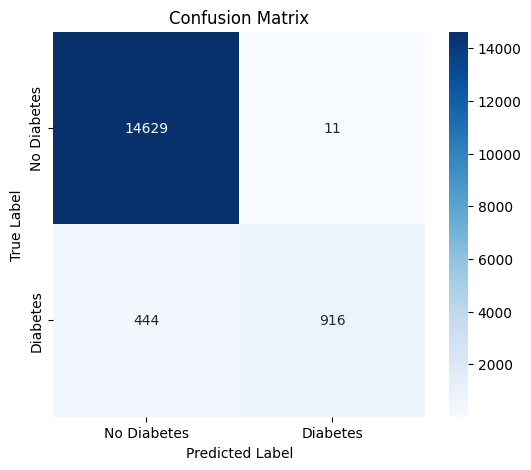

In [16]:
y_pred = best_f1_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/first_tuning_results.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [17]:
# import_experiment(best_f1_model, '01_f1_optimized')

### Experiment 1 / Param optimization

In [18]:
# Optimized parameter grid for Random Forest tuning.
# The goal is to find a better balance between recall and accuracy.
# Since the diabetes class is imbalanced, we test different class weights
# instead of using only None and "balanced".
opt_param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],

    # Handles class imbalance.
    # Custom weights help us test moderate focus on the diabetes class
    "class_weight": [
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

opt_param_grid_01 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=opt_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=3
)

opt_param_grid_01.fit(X_train, y_train)

best_model = opt_param_grid_01.best_estimator_

print(opt_param_grid_01.best_params_)
print(opt_param_grid_01.best_score_)

In [19]:
# import_experiment(best_model, '02_class_imbalanced')

### Experiment 2 / Param optimization

In [20]:
opt_param_grid_1 = {
    "n_estimators": [100, 200, 300],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],

    # Handles class imbalance.
    # Custom weights help us test moderate focus on the diabetes class
    "class_weight":  [
        None,
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

opt_param_grid_02 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=opt_param_grid,
    cv=5,
    n_jobs=-1,
    verbose=3
)

opt_param_grid_02.fit(X_train, y_train)

best_model = opt_param_grid_02.best_estimator_

print(opt_param_grid_02.best_params_)
print(opt_param_grid_02.best_score_)

In [21]:
y_proba = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve")
plt.legend()
plt.grid(True)

plt.show()

Conclusion:

RF achieving an ROC-AUC score of 0.9717. The curve remains
close to the upper-left corner, indicating that the model can effectively
distinguish between diabetic and non-diabetic patients.

At this stage, the primary objective is to reduce the number of False Negatives,
where patients with diabetes are incorrectly classified as healthy, while
preserving high model accuracy.

In [22]:
y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/opt_param_grid_02.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

### Experiment 3 / Param optimization

In [28]:
param_grid_experiment_3 = {
    "n_estimators": [100, 200, 300, 500],
    "max_depth": [10, 15, 20, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4, 6, 8],


    # Handles class imbalance.
    # Custom weights help us test moderate focus on the diabetes class
    "class_weight":  [
        None,
        "balanced",
        {0: 1, 1: 2},
        {0: 1, 1: 3},
        {0: 1, 1: 4}
    ]
}

param_grid_exp_3 = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid_experiment_3,
    cv=5,
    n_jobs=-1,
    verbose=3,
)

param_grid_exp_3.fit(X_train, y_train)

Fitting 5 folds for each of 1200 candidates, totalling 6000 fits


,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': [None, 'balanced', ...], 'max_depth': [10, 15, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...], ...}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,3
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [29]:
experiment_3 = param_grid_exp_3.best_estimator_

print(param_grid_exp_3.best_params_)
print(param_grid_exp_3.best_score_)

{'class_weight': {0: 1, 1: 2}, 'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 100}
0.9721250000000001


In [30]:
import_experiment(experiment_3, 'experiment_3')

Logged run 'experiment_3' in experiment 'Diabetes Prediction Based - Clinical and Demographic Features'


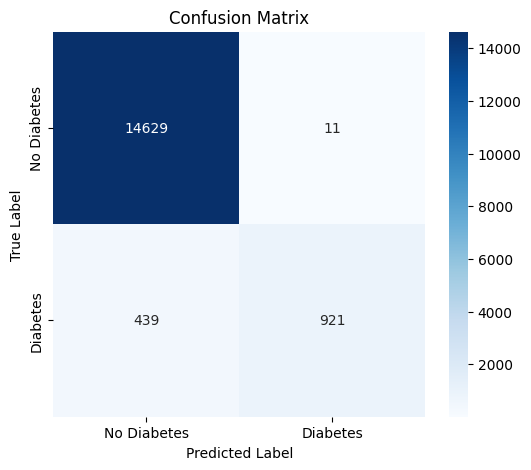

In [34]:
y_pred = experiment_3.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/experiment_3.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [214]:
# Create the directory for storing trained models if it does not already exist.
models_path = Path("../models")
models_path.mkdir(parents=True, exist_ok=True)

# Retrieve the best-performing Random Forest model found during GridSearchCV.
rf_model_experiment_3 = param_grid_exp_3.best_estimator_

# Save the trained model to disk so it can be loaded later without retraining.
joblib.dump(rf_model_experiment_3, models_path / "random_forest_experiment_3.pkl")

['..\\models\\random_forest_experiment_3.pkl']

### Threshold Analysis

After training the Random Forest model, the next step is to evaluate different classification thresholds. By default, predictions are converted into class labels using a threshold of **0.50**. Lowering or increasing this threshold changes the trade-off between recall, precision, and accuracy. The objective of this analysis is to identify a threshold that reduces the number of **False Negatives** (patients with diabetes incorrectly classified as healthy) while preserving high overall model accuracy.


In [222]:
rf_model_experiment_3 = joblib.load(
    models_path / "random_forest_experiment_3.pkl"
)

In [223]:
# Get predicted probabilities for the positive class.
y_proba = rf_model_experiment_3.predict_proba(X_test)[:, 1]

# Test different classification thresholds.
thresholds = [0.2, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]

for threshold in thresholds:
    y_pred_threshold = (y_proba >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_threshold)
    precision = precision_score(y_test, y_pred_threshold)
    recall = recall_score(y_test, y_pred_threshold)
    f1 = f1_score(y_test, y_pred_threshold)

    tn, fp, fn, tp = confusion_matrix(y_test, y_pred_threshold).ravel()

    print(f"Threshold: {threshold}")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")
    print(f"False Negatives: {fn}")
    print(f"False Positives: {fp}")
    print("-" * 40)

Threshold: 0.2
Accuracy:  0.9394
Precision: 0.6028
Recall:    0.8404
F1-score:  0.7021
False Negatives: 217
False Positives: 753
----------------------------------------
Threshold: 0.25
Accuracy:  0.9564
Precision: 0.7172
Recall:    0.8037
F1-score:  0.7580
False Negatives: 267
False Positives: 431
----------------------------------------
Threshold: 0.3
Accuracy:  0.9637
Precision: 0.7991
Recall:    0.7662
F1-score:  0.7823
False Negatives: 318
False Positives: 262
----------------------------------------
Threshold: 0.35
Accuracy:  0.9681
Precision: 0.8863
Recall:    0.7162
F1-score:  0.7922
False Negatives: 386
False Positives: 125
----------------------------------------
Threshold: 0.4
Accuracy:  0.9710
Precision: 0.9427
Recall:    0.7015
F1-score:  0.8044
False Negatives: 406
False Positives: 58
----------------------------------------
Threshold: 0.45
Accuracy:  0.9716
Precision: 0.9699
Recall:    0.6868
F1-score:  0.8041
False Negatives: 426
False Positives: 29
--------------------

### Loading Validation Data

In this step, the validation dataset is loaded and used to evaluate the final trained model on unseen data. This allows us to check how well the model generalizes beyond the training and test sets, and whether the selected threshold performs reliably on new observations.

In [224]:
val_data_experiment = val_data.copy()

In [225]:
val_dataset = val_data_experiment.drop(columns=['diabetes'])
val_target = val_data_experiment['diabetes']

In [226]:
threshold = 0.25

In [227]:
val_proba = rf_model_experiment_3.predict_proba(val_dataset)[:, 1]
val_pred = (val_proba >= 0.25).astype(int)

In [228]:
# Calculate evaluation metrics.
print("Validation Results")
print(f"Accuracy:  {accuracy_score(val_target, val_pred):.4f}")
print(f"Precision: {precision_score(val_target, val_pred):.4f}")
print(f"Recall:    {recall_score(val_target, val_pred):.4f}")
print(f"F1-score:  {f1_score(val_target, val_pred):.4f}")

# Show confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(val_target, val_pred))

# Show full classification report.
print("\nClassification Report:")
print(classification_report(val_target, val_pred))

Validation Results
Accuracy:  0.9551
Precision: 0.7073
Recall:    0.8047
F1-score:  0.7529

Confusion Matrix:
[[17734   566]
 [  332  1368]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98     18300
         1.0       0.71      0.80      0.75      1700

    accuracy                           0.96     20000
   macro avg       0.84      0.89      0.86     20000
weighted avg       0.96      0.96      0.96     20000



In [229]:
332 / 20000 * 100

1.66

In [230]:
proba_1 = rf_model_experiment_3.predict_proba(X_test)[:, 1]
proba_1_pred = (proba_1 >= 0.25).astype(int)

In [241]:
# Calculate evaluation metrics.
print("Validation Results")
print(f"Accuracy:  {accuracy_score(y_test, proba_1_pred):.4f}")
print(f"Precision: {precision_score(y_test, proba_1_pred):.4f}")
print(f"Recall:    {recall_score(y_test, proba_1_pred):.4f}")
print(f"F1-score:  {f1_score(y_test, proba_1_pred):.4f}")

# Show confusion matrix.
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, proba_1_pred))

# Show full classification report.
print("\nClassification Report:")
print(classification_report(y_test, proba_1_pred))

Validation Results
Accuracy:  0.9564
Precision: 0.7172
Recall:    0.8037
F1-score:  0.7580

Confusion Matrix:
[[14209   431]
 [  267  1093]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.98      0.97      0.98     14640
         1.0       0.72      0.80      0.76      1360

    accuracy                           0.96     16000
   macro avg       0.85      0.89      0.87     16000
weighted avg       0.96      0.96      0.96     16000



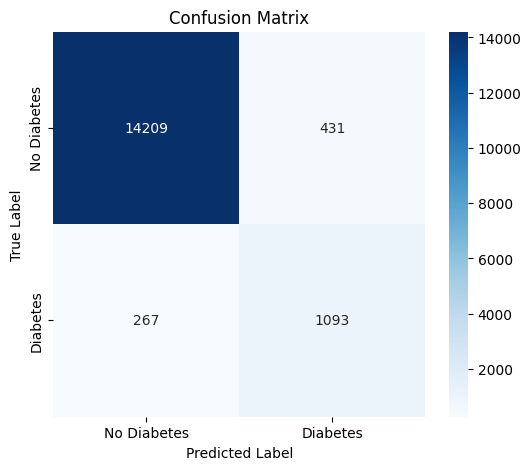

In [243]:
y_pred = experiment_3.predict(X_test)

cm = confusion_matrix(y_test, proba_1_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=True,
    xticklabels=['No Diabetes', 'Diabetes'],
    yticklabels=['No Diabetes', 'Diabetes']
)

# Save the figure
plt.savefig('../reports/figures/experiment_3_025_th.png',
            dpi=300,
            bbox_inches='tight')

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

plt.show()

In [232]:
267 / 16000 * 100

1.6687500000000002

In [233]:
feature_importances = pd.DataFrame({
    "feature": X_train.columns,
    "importance": rf_model_experiment_3.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importances

,feature,importance
13,scaler__hba1c_level,0.450169
14,scaler__blood_glucose_level,0.363513
9,scaler__age,0.076222
12,scaler__bmi,0.046010
10,scaler__hypertension,0.029627
11,scaler__heart_disease,0.018148
3,smoking_history_no info,0.008064
6,smoking_history_former,0.002923
0,gender_female,0.001552
1,gender_male,0.001285


### Test vs Validation Performance

The model achieved very similar results on both the test and validation datasets. This indicates that the model generalizes well to unseen data and does not show clear signs of overfitting.

The lower performance on the positive class (diabetes) is likely influenced by class imbalance. Since there are fewer diabetic patients in the training data, the model has fewer examples to learn their characteristics, making it more difficult to correctly identify all positive cases.

## Adding an Additional Dataset

To improve the model performance, especially for the positive class, we will add one additional dataset to the project.

The main idea is to find more records of patients who are diagnosed with diabetes. In the current dataset, the number of observations for class `1` is limited compared to class `0`, which may make it harder for the model to learn stable patterns for diabetic patients.

The second dataset will be processed and aligned with the main dataset by keeping the same feature structure where possible. After that, the two datasets will be combined into one larger training dataset.

By adding more diagnosed diabetes cases, we expect the new model to have more examples from the minority class during training. This may help improve the model's ability to correctly identify diabetic patients, especially in terms of recall and F1-score for class `1`.

The final goal is to train a new model on the combined dataset and compare its performance with the previous model trained only on the original data.

In [175]:
first_dataset = pd.read_csv('../data/processed/working_dataset.csv')
first_dataset = first_dataset.copy()

In [176]:
first_dataset["age"] = pd.cut(
    first_dataset["age"],
    bins=[0, 25, 30, 35, 40, 45, 50, 55, 60, 65, 70, 75, 80, float("inf")],
    labels=[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
    right=False
)

first_dataset["age"] = first_dataset["age"].astype("Int64")

In [177]:
second_dataset = pd.read_csv('../data/raw/diabetes_binary_health_indicators_BRFSS2015.csv')
# Source link to the original dataset: https://www.kaggle.com/datasets/alexteboul/diabetes-health-indicators-dataset?utm_source=chatgpt.com&select=diabetes_binary_health_indicators_BRFSS2015.csv

second_dataset = second_dataset[['Diabetes_binary', 'BMI', 'HighBP', 'Age']].copy()
second_dataset = second_dataset.rename(columns={
    "Diabetes_binary": "diabetes",
    "BMI": "bmi",
    "HighBP": "hypertension",
    "Age": "age"
})

In [178]:
first_dataset.columns

Index(['gender', 'age', 'hypertension', 'heart_disease', 'smoking_history',
       'bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes'],
      dtype='object')

In [179]:
second_dataset.columns

Index(['diabetes', 'bmi', 'hypertension', 'age'], dtype='object')

In [183]:
combined_dataset = pd.concat(
    [first_dataset, second_dataset],
    ignore_index=True
)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,13.0,0.0,1.0,never,25.19,6.6,140.0,0.0
1,Female,7.0,0.0,0.0,No Info,27.32,6.6,80.0,0.0
2,Male,2.0,0.0,0.0,never,27.32,5.7,158.0,0.0
3,Female,4.0,0.0,0.0,current,23.45,5.0,155.0,0.0
4,Male,12.0,1.0,1.0,current,20.14,4.8,155.0,0.0
...,...,...,...,...,...,...,...,...,...
353675,NaN,5.0,1.0,NaN,NaN,45.00,NaN,NaN,0.0
353676,NaN,11.0,1.0,NaN,NaN,18.00,NaN,NaN,1.0
353677,NaN,2.0,0.0,NaN,NaN,28.00,NaN,NaN,0.0
353678,NaN,7.0,1.0,NaN,NaN,23.00,NaN,NaN,0.0


In [186]:
combined_dataset.isna().sum()

gender                 253680
age                         0
hypertension                0
heart_disease          253680
smoking_history        253680
bmi                         0
HbA1c_level            253680
blood_glucose_level    253680
diabetes                    0
dtype: int64

In [240]:
combined_dataset_for_training

,age,hypertension,bmi,diabetes
0,13.0,0.0,25.19,0.0
1,7.0,0.0,27.32,0.0
2,2.0,0.0,27.32,0.0
3,4.0,0.0,23.45,0.0
4,12.0,1.0,20.14,0.0
...,...,...,...,...
353675,5.0,1.0,45.00,0.0
353676,11.0,1.0,18.00,1.0
353677,2.0,0.0,28.00,0.0
353678,7.0,1.0,23.00,0.0


In [194]:
combined_dataset_for_training = combined_dataset[['age', 'hypertension', 'bmi', 'diabetes']]
combined_dataset_for_training.isna().sum()

age             0
hypertension    0
bmi             0
diabetes        0
dtype: int64

In [234]:
arguments = combined_dataset_for_training.drop(columns=['diabetes'])
targets = combined_dataset_for_training['diabetes']

In [235]:
arguments_train, arguments_test, targets_train, targets_test = train_test_split(arguments, targets, stratify=targets, random_state=42, test_size=0.2)

In [236]:
comb_rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

In [237]:
comb_rf_model.fit(arguments_train, targets_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [238]:
y_pred = comb_rf_model.predict(arguments_test)

In [239]:
accuracy = accuracy_score(targets_test, y_pred)
precision = precision_score(targets_test, y_pred)
recall = recall_score(targets_test, y_pred)
f1 = f1_score(targets_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

print("\nClassification Report:")
print(classification_report(targets_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(targets_test, y_pred))

Accuracy: 0.8694158561411446
Precision: 0.34665792922673655
Recall: 0.06032614893374387
F1-score: 0.10276833414278776

Classification Report:
              precision    recall  f1-score   support

         0.0       0.88      0.98      0.93     61967
         1.0       0.35      0.06      0.10      8769

    accuracy                           0.87     70736
   macro avg       0.61      0.52      0.52     70736
weighted avg       0.81      0.87      0.83     70736


Confusion Matrix:
[[60970   997]
 [ 8240   529]]


## Conclusion

The model trained on the combined dataset achieved significantly worse performance in detecting diabetic patients compared to the model trained on the original dataset.

Although the combined dataset contained substantially more observations, the additional dataset did not include several important clinical features, such as **HbA1c level**, **blood glucose level**, **heart disease**, **smoking history**, and **gender**. As a result, the model had to be trained using only the features shared by both datasets.

The classification report shows that the model achieved a **recall of only 0.06** for the positive class, meaning that it correctly identified only **6% of patients diagnosed with diabetes**. This indicates that the available features were not sufficiently informative for distinguishing diabetic patients.

The feature importance results support the same conclusion. The most influential features in the original experiment are missing from the second dataset. This suggests that a larger number of observations alone is not enough to improve the model.

For accurate diabetes prediction, the model needs more relevant medical features, such as HbA1c level and blood glucose level. Without these variables, the model has limited information and struggles to correctly identify patients diagnosed with diabetes.